# 31/10/03 - Estudos de redes com de 3 a 7 camadas e de 16 a 64 neurônios



## Resumo

- Função de perda: RMSE
- Funções de  ativação: 
    - Tanh

- Tamanhos de batelada:
    - 1e4

- Numero de épocas:
    - 1e4

- Arquivo de checkpoint: 
    - 1751303057

- Peso da perda de pde: 5


## Análise de erro vs speedup

In [1]:
import glob
import pickle as pk
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd 

In [3]:
def retrieve_betas(beta):
    return beta.split("_")[-1]


def extract_architecture_info(file):
    """
    Extrai betas, arquitetura, número de camadas e número total de neurônios
    a partir do nome do arquivo.
    """

    file_name = file.split("/")[-1].split(".pkl")[0]

    # Remove prefixos
    file_name = file_name.replace("pinn__output_", "")
    file_name = file_name.replace("nn__output_", "")

    parts = file_name.split("__")

    betas = "__".join(
        list(map(retrieve_betas, parts[:2]))
    )

    layers_list = parts[2:]

    arch_name = "__".join(layers_list)

    n_layers = len(layers_list)

    n_neurons = 0

    for layer in layers_list:
        n_neurons += int(layer.split("--")[-1])

    return {
        "betas": betas,
        "arch_name": arch_name,
        "n_layers": n_layers,
        "n_neurons": n_neurons,
    }

def build_results_dict(result_list, model_type):
    """
    Lê os arquivos de saída e organiza os resultados.

    model_type:
        "pinn" ou "nn"
    """

    results_dict = {}

    i = 0

    mean_error_key = f"{model_type}_mean_ae"

    for file in result_list:

        with open(file, "rb") as f:
            aux_dict = pk.load(f)

        if mean_error_key not in aux_dict:
            continue

        if np.isnan(aux_dict[mean_error_key]):
            continue

        results_dict[i] = aux_dict.copy()

        results_dict[i]["model_type"] = model_type

        results_dict[i]["file"] = file.split("/")[-1]

        arch_info = extract_architecture_info(file)

        results_dict[i].update(arch_info)

        i += 1

    return results_dict

def standardize_metrics(row):
    model_type = row["model_type"]

    return pd.Series({
        "mean_ae": row.get(f"{model_type}_mean_ae", np.nan),
        "std_ae": row.get(f"{model_type}_std_ae", np.nan),
        "max_ae": row.get(f"{model_type}_max_ae", np.nan),

        "mean_fold_mae": row.get(f"{model_type}_mean_fold_mae", np.nan),
        "std_fold_mae": row.get(f"{model_type}_std_fold_mae", np.nan),
        "max_fold_mae": row.get(f"{model_type}_max_fold_mae", np.nan),

        "mean_train_time": row.get(f"{model_type}_mean_train_time", np.nan),
        "std_train_time": row.get(f"{model_type}_std_train_time", np.nan),

        "mean_test_time": row.get(f"{model_type}_mean_test_time", np.nan),
        "std_test_time": row.get(f"{model_type}_std_test_time", np.nan),

        "mean_speed_up": row.get(f"{model_type}_mean_speed_up", np.nan),
        "std_speed_up": row.get(f"{model_type}_std_speed_up", np.nan),
    })


In [4]:
pinn_result_list = glob.glob("nn_sim/pinn__output_*.pkl")
nn_result_list = glob.glob("nn_sim/nn__output_*.pkl")

pinn_results_dict = build_results_dict(
    pinn_result_list,
    model_type="pinn"
)

nn_results_dict = build_results_dict(
    nn_result_list,
    model_type="nn"
)

all_results_dict = {}

i = 0

for result in pinn_results_dict.values():
    all_results_dict[i] = result
    i += 1

for result in nn_results_dict.values():
    all_results_dict[i] = result
    i += 1

In [5]:
pinn_df = pd.DataFrame.from_dict(
    pinn_results_dict,
    orient="index"
)

nn_df = pd.DataFrame.from_dict(
    nn_results_dict,
    orient="index"
)

results_df = pd.concat(
    [pinn_df, nn_df],
    ignore_index=True
)

standard_metrics = results_df.apply(
    standardize_metrics,
    axis=1
)

results_df = pd.concat(
    [results_df, standard_metrics],
    axis=1
)

In [6]:
x_lim = (0.0, 2.0)

error_col = "mean_ae"
speed_col = "mean_speed_up"

# Filtra apenas modelos válidos
df = results_df.copy()
df = df.dropna(subset=[error_col, speed_col])

results_df.groupby("model_type")[
    [
        "mean_ae",
        "max_ae",
        "mean_train_time",
        "mean_test_time",
        "mean_speed_up",
    ]
].mean()

,mean_ae,max_ae,mean_train_time,mean_test_time,mean_speed_up
model_type,,,,,
nn,0.014010,0.587007,24.174261,0.003598,534.718748
pinn,0.130719,0.816063,433.074733,0.003693,507.191696



PINN


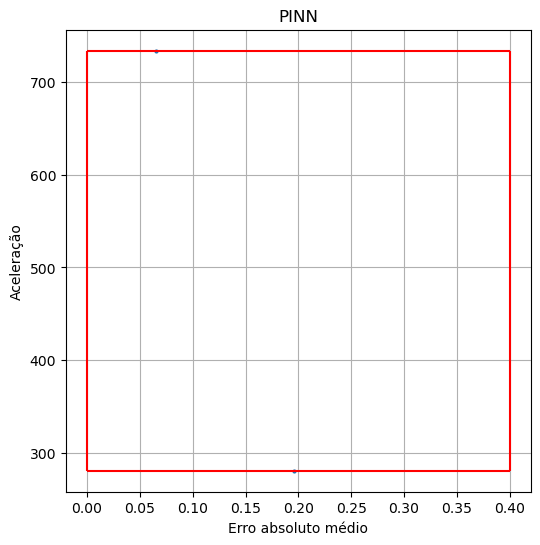

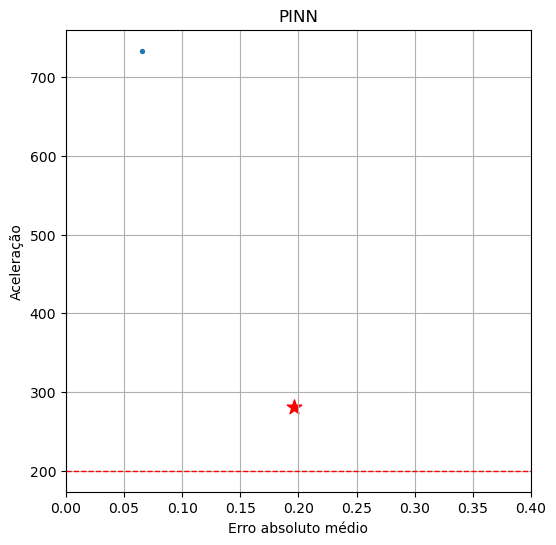

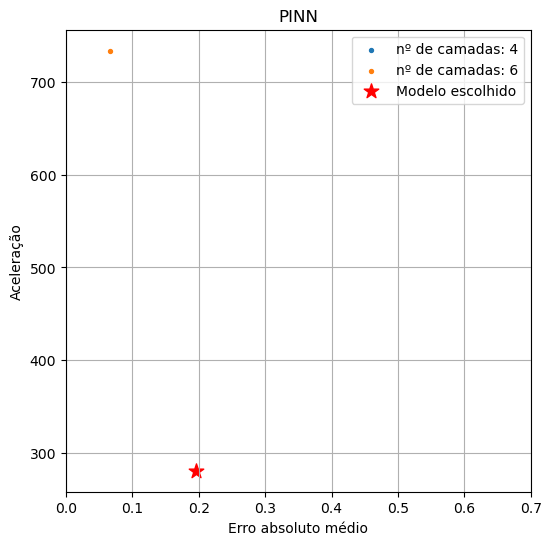

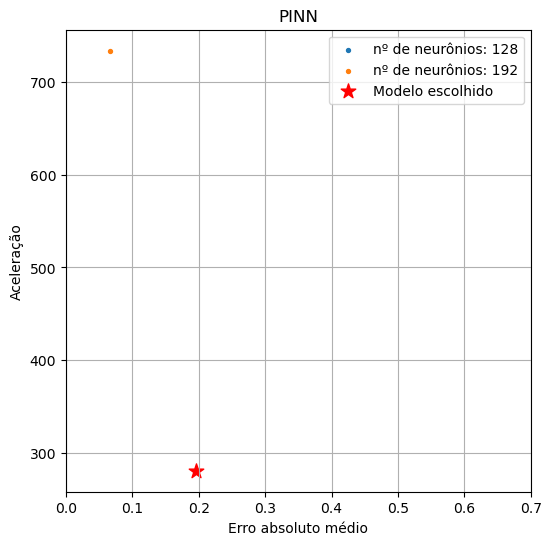

Arquitetura escolhida: ReLU--32__Tanh--32__ReLU--32__Tanh--32
Tipo de modelo: pinn
Best betas: 0.9__0.9999
Erro absoluto médio: 0.19578378840047123
Erro absoluto máximo: 0.9946981986911481
Aceleração: 280.94627125488006 +/- 25.957573003375217
Tempo de treino: 378.30458199977875 +/- 2.2931063462304073
Tempo de teste: 0.0053299665451049805 +/- 0.0006964345247940129

NN


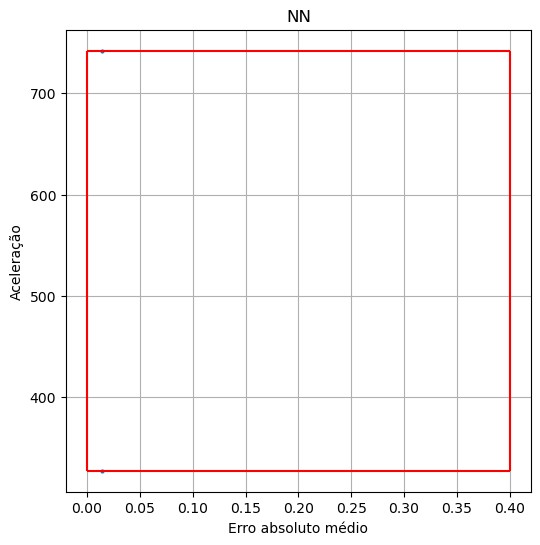

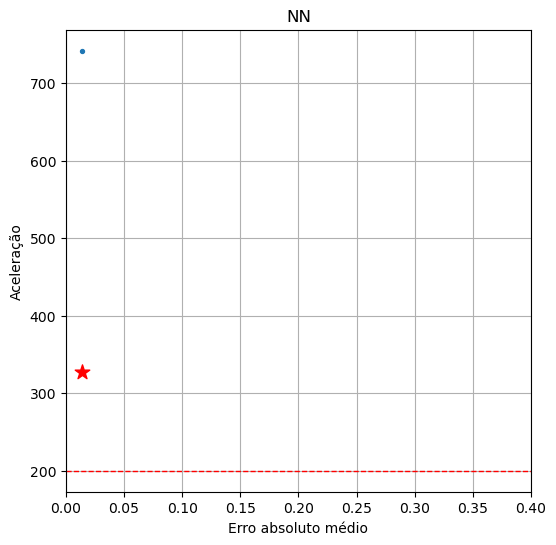

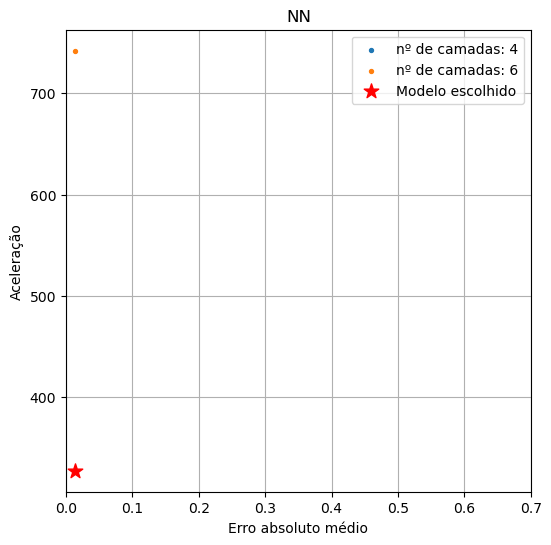

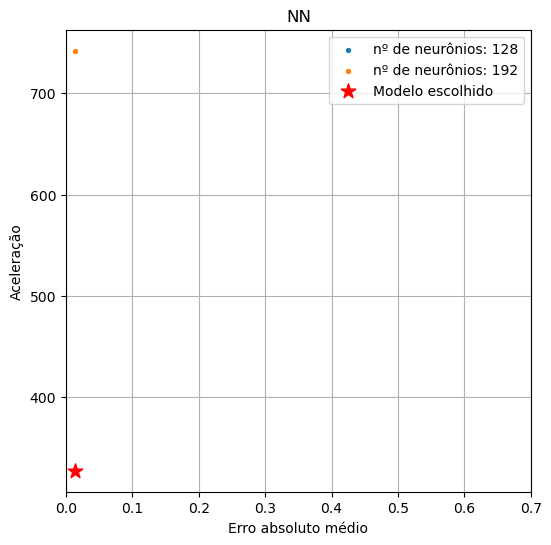

Arquitetura escolhida: ReLU--32__Tanh--32__ReLU--32__Tanh--32
Tipo de modelo: nn
Best betas: 0.9__0.9999
Erro absoluto médio: 0.01383511969618627
Erro absoluto máximo: 0.588597368876099
Aceleração: 327.464704272841 +/- 102.79018414006575
Tempo de treino: 20.865076422691345 +/- 0.05801243957694094
Tempo de teste: 0.00502932071685791 +/- 0.0022326028593190788


In [7]:
import numpy as np
import matplotlib.pyplot as plt


error_col = "mean_ae"
speed_col = "mean_speed_up"

x_lim = (0, 0.4)

max_error_allowed = 60
min_speed_allowed = 200

pinn_best_model = None
nn_best_model = None


for model_type in ["pinn", "nn"]:

    sub_results_df = results_df[
        results_df["model_type"] == model_type
    ].reset_index(drop=True)

    print("\n" + "=" * 30)
    print(model_type.upper())
    print("=" * 30)

    # --- Gráfico 1 ---
    fig1, ax1 = plt.subplots(figsize=(6, 6))

    ax1.scatter(
        sub_results_df[error_col],
        sub_results_df[speed_col],
        s=4,
    )

    ax1.hlines(
        max(sub_results_df[speed_col]),
        x_lim[0],
        x_lim[1],
        color="r",
    )

    ax1.hlines(
        min(sub_results_df[speed_col]),
        x_lim[0],
        x_lim[1],
        color="r",
    )

    ax1.vlines(
        x_lim[1],
        min(sub_results_df[speed_col]),
        max(sub_results_df[speed_col]),
        color="r",
    )

    ax1.vlines(
        x_lim[0],
        min(sub_results_df[speed_col]),
        max(sub_results_df[speed_col]),
        color="r",
    )

    ax1.set_xlabel("Erro absoluto médio")
    ax1.set_ylabel("Aceleração")
    ax1.set_title(model_type.upper())
    ax1.grid()
    plt.show()

    # --- Escolha do modelo ---
    choice_array = np.intersect1d(
        np.argwhere(np.array(sub_results_df[speed_col]) > min_speed_allowed),
        np.argwhere(np.array(sub_results_df[error_col]) < max_error_allowed),
    )

    if len(choice_array) == 0:
        print("Nenhum modelo satisfez os critérios definidos.")
        continue

    choice = choice_array[0]

    best_model = sub_results_df.iloc[choice]

    if model_type == "pinn":
        pinn_best_model = best_model

    elif model_type == "nn":
        nn_best_model = best_model

    # --- Gráfico 2 ---
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.scatter(
        sub_results_df[error_col],
        sub_results_df[speed_col],
        s=8,
    )

    ax2.scatter(
        sub_results_df[error_col][choice],
        sub_results_df[speed_col][choice],
        c="r",
        marker="*",
        s=120,
    )

    ax2.axvline(
        max_error_allowed,
        color="r",
        linestyle="--",
        linewidth=1,
    )

    ax2.axhline(
        min_speed_allowed,
        color="r",
        linestyle="--",
        linewidth=1,
    )

    ax2.set_xlim(x_lim[0], x_lim[1])
    ax2.set_xlabel("Erro absoluto médio")
    ax2.set_ylabel("Aceleração")
    ax2.set_title(model_type.upper())
    ax2.grid()
    plt.show()

    # --- Gráfico 3 ---
    fig3, ax3 = plt.subplots(figsize=(6, 6))

    unique_n_layers = np.unique(sub_results_df.n_layers)

    for n_layers in unique_n_layers:

        sub_df = sub_results_df[
            sub_results_df.n_layers == int(n_layers)
        ]

        ax3.scatter(
            sub_df[error_col],
            sub_df[speed_col],
            s=8,
            label=f"nº de camadas: {int(n_layers)}",
        )

    ax3.scatter(
        best_model[error_col],
        best_model[speed_col],
        c="r",
        marker="*",
        s=120,
        label="Modelo escolhido",
    )

    ax3.set_xlabel("Erro absoluto médio")
    ax3.set_ylabel("Aceleração")
    ax3.set_xlim(x_lim[0], 0.7)
    ax3.set_title(model_type.upper())
    ax3.legend()
    ax3.grid()
    plt.show()

    # --- Gráfico 4 ---
    fig4, ax4 = plt.subplots(figsize=(6, 6))

    unique_n_neurons = np.unique(sub_results_df.n_neurons)

    for n_neurons in unique_n_neurons:

        sub_df = sub_results_df[
            sub_results_df.n_neurons == int(n_neurons)
        ]

        ax4.scatter(
            sub_df[error_col],
            sub_df[speed_col],
            s=8,
            label=f"nº de neurônios: {int(n_neurons)}",
        )

    ax4.scatter(
        best_model[error_col],
        best_model[speed_col],
        c="r",
        marker="*",
        s=120,
        label="Modelo escolhido",
    )

    ax4.set_xlabel("Erro absoluto médio")
    ax4.set_ylabel("Aceleração")
    ax4.set_xlim(x_lim[0], 0.7)
    ax4.set_title(model_type.upper())
    ax4.legend()
    ax4.grid()
    plt.show()

    # --- Prints ---
    print("Arquitetura escolhida:", best_model["arch_name"])
    print("Tipo de modelo:", best_model["model_type"])
    print("Best betas:", best_model["betas"])
    print("Erro absoluto médio:", best_model["mean_ae"])
    print("Erro absoluto máximo:", best_model["max_ae"])

    print(
        "Aceleração: {} +/- {}".format(
            best_model["mean_speed_up"],
            best_model["std_speed_up"],
        )
    )

    print(
        "Tempo de treino: {} +/- {}".format(
            best_model["mean_train_time"],
            best_model["std_train_time"],
        )
    )

    print(
        "Tempo de teste: {} +/- {}".format(
            best_model["mean_test_time"],
            best_model["std_test_time"],
        )
    )


PINN


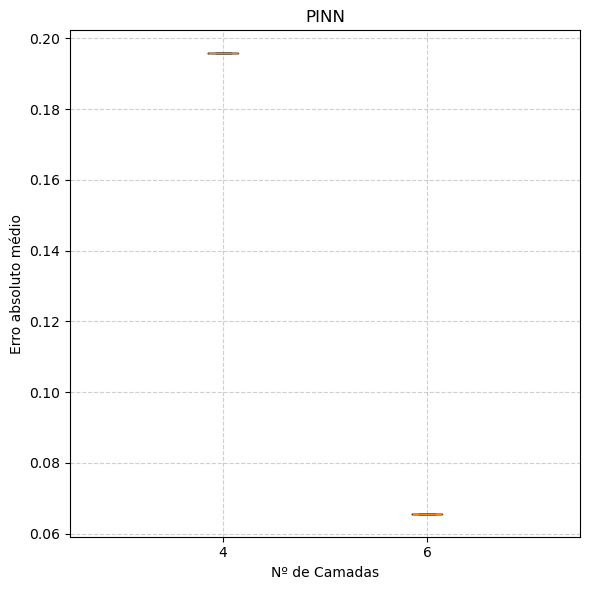

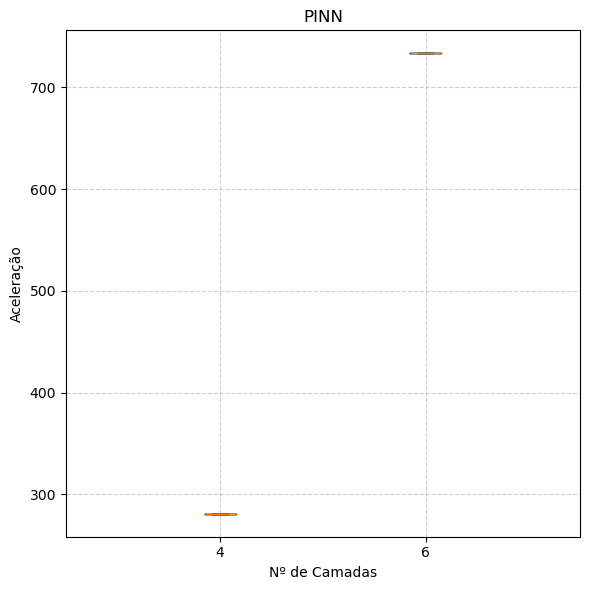

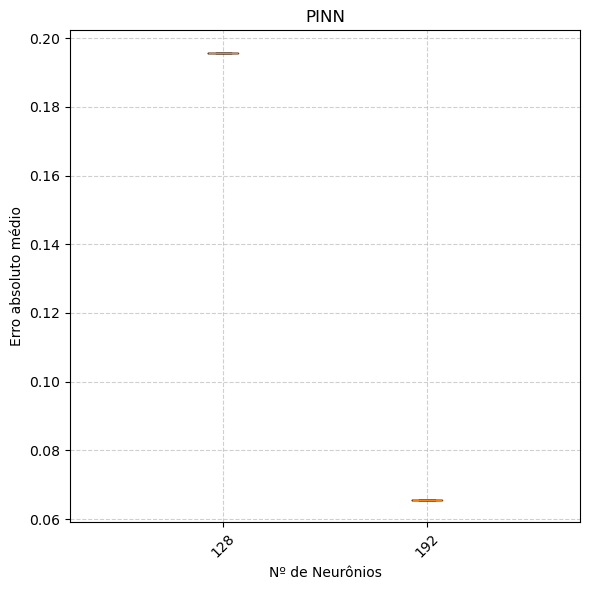

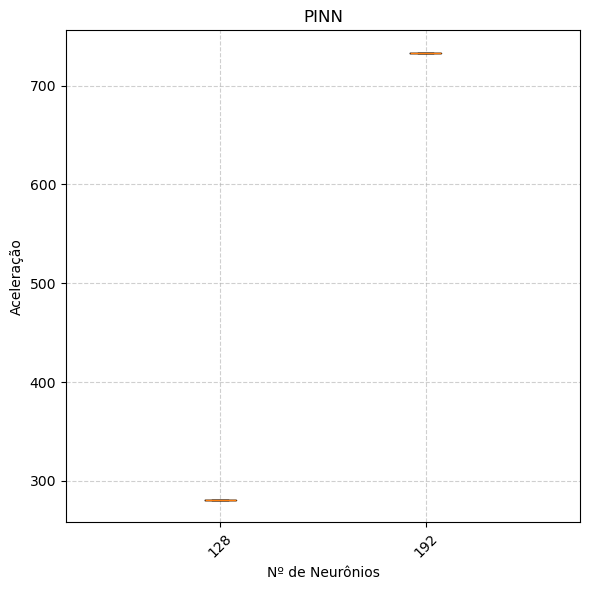


NN


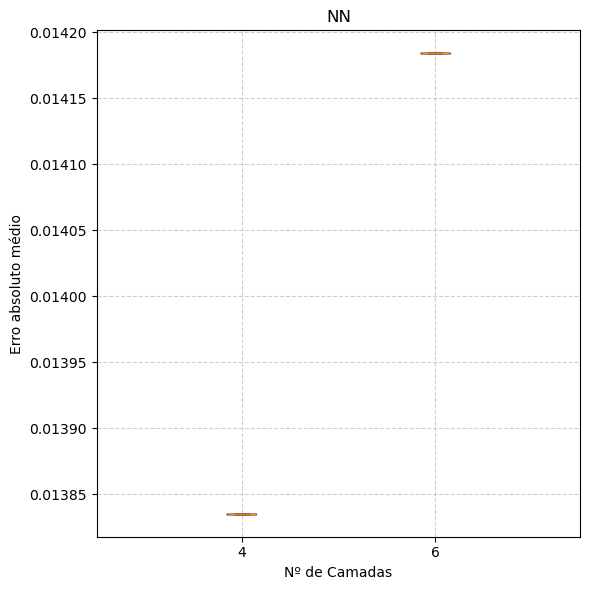

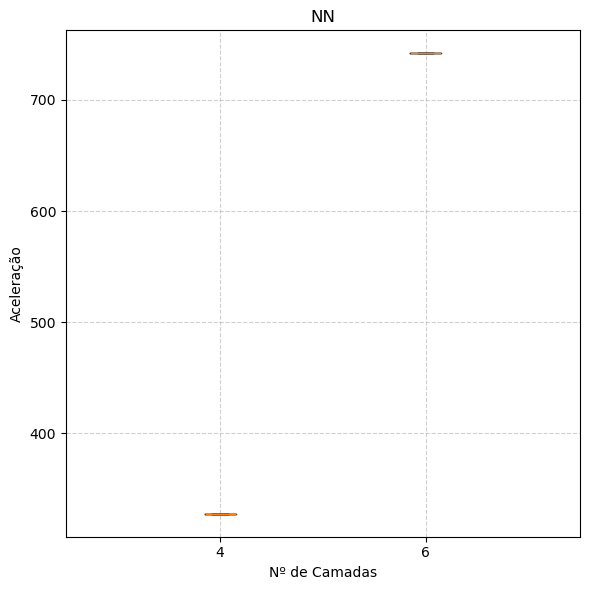

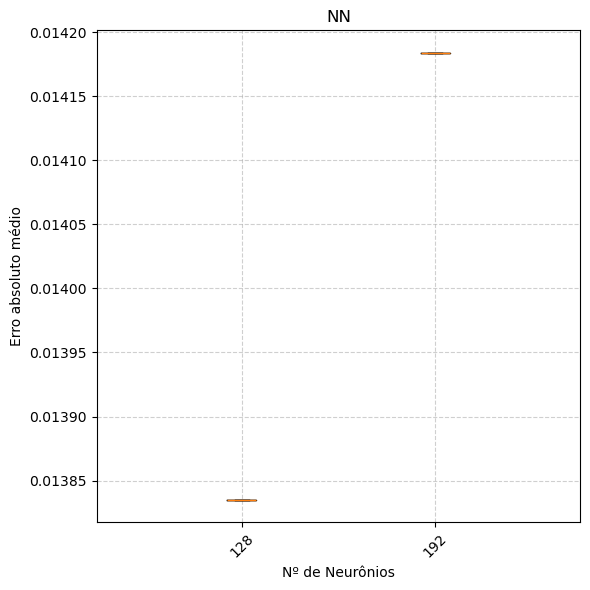

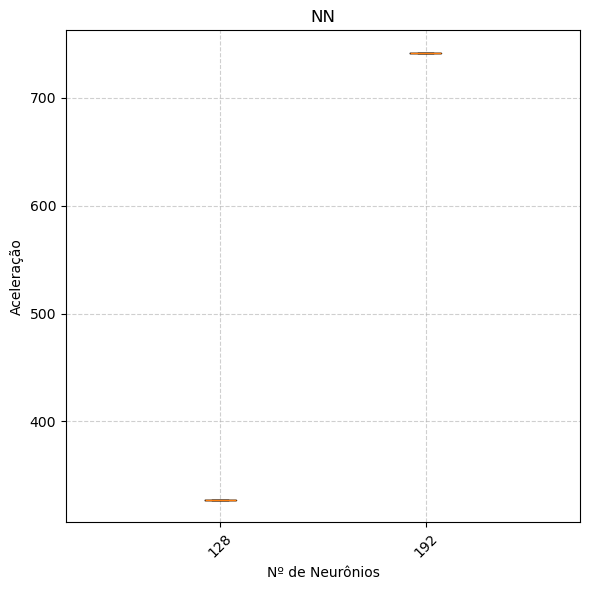

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def set_axis_style(ax, labels, xlabel, ylabel):

    ax.set_xticks(np.arange(1, len(labels) + 1))

    ax.set_xticklabels(labels)

    ax.set_xlim(0.25, len(labels) + 0.75)

    ax.set_xlabel(xlabel)

    ax.set_ylabel(ylabel)

    ax.grid(True, linestyle="--", alpha=0.6)


# Novas colunas
error_col = "mean_ae"
speed_col = "mean_speed_up"


for model_type in ["pinn", "nn"]:

    sub_results_df = results_df[
        results_df["model_type"] == model_type
    ].copy()

    print("\n" + "=" * 30)
    print(model_type.upper())
    print("=" * 30)

    # =====================================================
    # Gráfico 1: erro absoluto médio por nº de camadas
    # =====================================================

    fig1, ax1 = plt.subplots(figsize=(6, 6))

    unique_n_layers = np.unique(sub_results_df.n_layers)

    collection = [
        sub_results_df[
            sub_results_df.n_layers == n
        ][error_col]
        for n in unique_n_layers
    ]

    ax1.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_layers) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax1,
        unique_n_layers,
        "Nº de Camadas",
        "Erro absoluto médio",
    )

    ax1.set_title(model_type.upper())

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Gráfico 2: aceleração por nº de camadas
    # =====================================================

    fig2, ax2 = plt.subplots(figsize=(6, 6))

    collection = [
        sub_results_df[
            sub_results_df.n_layers == n
        ][speed_col]
        for n in unique_n_layers
    ]

    ax2.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_layers) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax2,
        unique_n_layers,
        "Nº de Camadas",
        "Aceleração",
    )

    ax2.set_title(model_type.upper())

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Gráfico 3: erro absoluto médio por nº de neurônios
    # =====================================================

    fig3, ax3 = plt.subplots(figsize=(6, 6))

    unique_n_neurons = np.unique(sub_results_df.n_neurons)

    collection = [
        sub_results_df[
            sub_results_df.n_neurons == n
        ][error_col]
        for n in unique_n_neurons
    ]

    ax3.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_neurons) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax3,
        unique_n_neurons,
        "Nº de Neurônios",
        "Erro absoluto médio",
    )

    ax3.set_title(model_type.upper())

    plt.setp(ax3.get_xticklabels(), rotation=45)

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Gráfico 4: aceleração por nº de neurônios
    # =====================================================

    fig4, ax4 = plt.subplots(figsize=(6, 6))

    collection = [
        sub_results_df[
            sub_results_df.n_neurons == n
        ][speed_col]
        for n in unique_n_neurons
    ]

    ax4.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_neurons) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax4,
        unique_n_neurons,
        "Nº de Neurônios",
        "Aceleração",
    )

    ax4.set_title(model_type.upper())

    plt.setp(ax4.get_xticklabels(), rotation=45)

    plt.tight_layout()

    plt.show()

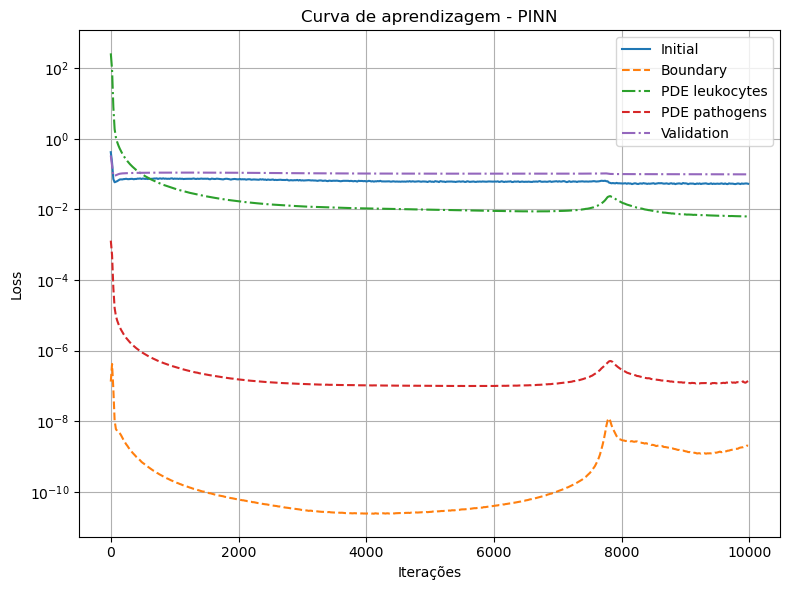

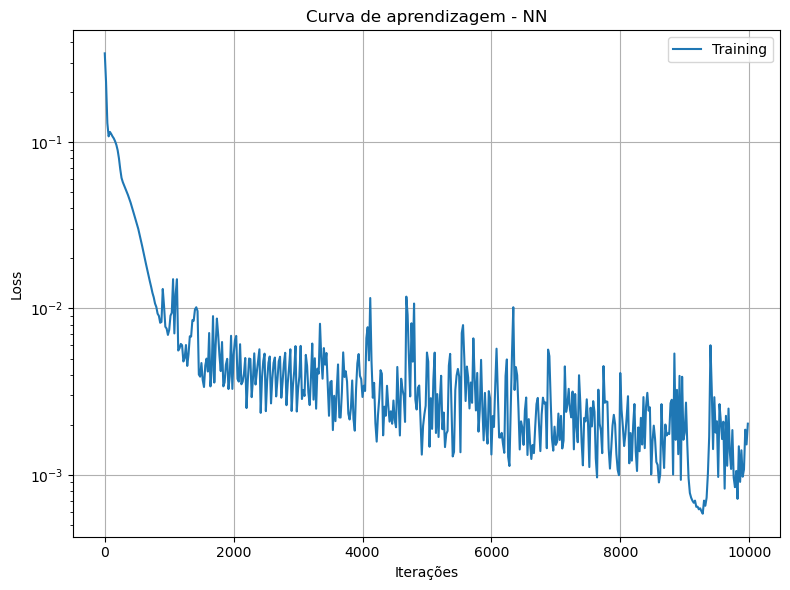

In [ ]:
import os
import matplotlib.pyplot as plt
import pickle as pk


sampling_step = 20

best_models = {
    "pinn": pinn_best_model,
    "nn": nn_best_model,
}


for model_type, best_model in best_models.items():

    if best_model is None:
        print(f"Nenhum melhor modelo definido para {model_type.upper()}.")
        continue

    file_name = best_model["file"]

    # Ajusta o nome do arquivo de saída para o nome da curva de aprendizagem
    file_name = file_name.replace("pinn__output_", "pinn__")
    file_name = file_name.replace("nn__output_", "nn__")

    learning_curve_path = os.path.join(
        "learning_curves",
        file_name,
    )

    with open(learning_curve_path, "rb") as f:
        loss_dict = pk.load(f)

    fig = plt.figure(figsize=[8, 6])
    ax = fig.add_subplot(1, 1, 1)

    ax.set_xlabel("Iterações")
    ax.set_ylabel("Loss")
    ax.set_title(f"Curva de aprendizagem - {model_type.upper()}")

    if model_type == "pinn":

        labels = [
            "Initial",
            "Boundary",
            "PDE leukocytes",
            "PDE pathogens",
            "Validation",
        ]

        markers = [
            "-",
            "--",
            "-.",
            "--",
            "-.",
        ]

    else:

        labels = [
            "Training",
            "Validation",
        ]

        markers = [
            "-",
            "--",
        ]

    for loss, label, marker in zip(loss_dict, labels, markers):

        sampled_x = range(
            0,
            len(loss_dict[loss]),
            sampling_step,
        )

        sampled_y = loss_dict[loss][::sampling_step]

        ax.plot(
            sampled_x,
            sampled_y,
            marker,
            label=label,
        )

    ax.set_yscale("log")

    ax.grid()
    ax.legend()

    #ax.set_xlim(0, 1300)

    plt.tight_layout()
    plt.show()

In [ ]:
import pickle as pk
import json
from pinn import *

# Opening JSON file
with open("control_dicts/constant_properties.json", "r") as openfile:
    # Reading from json file
    constant_properties = json.load(openfile)

central_ini_cond = constant_properties["central_ini_cond"]

# Opening JSON file
with open("control_dicts/mesh_properties.json", "r") as openfile:
    # Reading from json file
    mesh_properties = json.load(openfile)

h = mesh_properties["h"]
k = mesh_properties["k"]
x_dom = mesh_properties["x_dom"]
y_dom = mesh_properties["y_dom"]
t_dom = mesh_properties["t_dom"]


Cl_list, Cp_list, speed_up_list = read_files("fvm_sim")

Cp_fvm, Cl_fvm, center, radius = format_array(Cp_list[0], Cl_list[0])

size_x, size_y, size_t = get_mesh_properties(x_dom, y_dom, t_dom, h, k)

with open("source_points/lymph_vessels.pkl", "rb") as f:
    leu_source_points = pk.load(f)

(
    initial_tc,
    center_x_tc,
    radius_tc,
    data_tc,
    target_tc,
    device,
) = allocates_training_mesh(
    t_dom,
    x_dom,
    size_t,
    size_x,
    center[0],
    central_ini_cond,
    radius,
    Cl_fvm,
    Cp_fvm,
)

Steps in time = 5000
Steps in space_x = 40
Steps in space_y = 1

device: cuda


Carregando modelo: nn_parameters/pinn__beta1_0.9__beta2_0.9999__ReLU--32__Tanh--32__ReLU--32__Tanh--32.pt


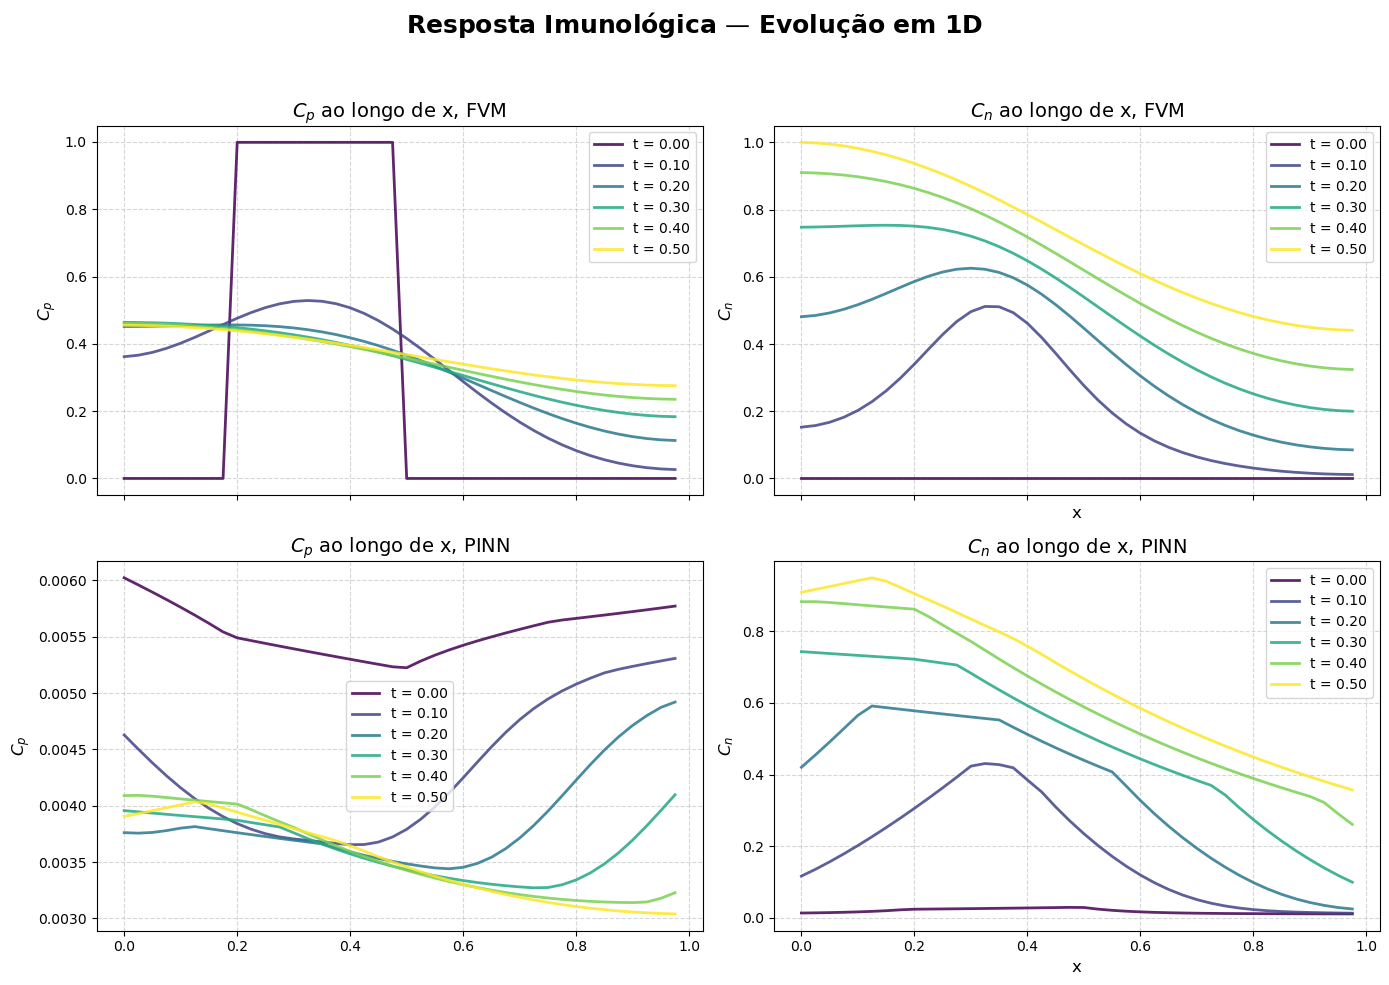

In [ ]:
from grid_search import normalize_target
from plots import plot_comparison

# =====================================================
# Normaliza o target completo
# =====================================================

min_cl, min_cp, delta_cl, delta_cp, target_norm = normalize_target(target_tc)

target_norm_np = target_norm.detach().cpu().numpy()

Cl_target_norm_np, Cp_target_norm_np = np.split(target_norm_np, 2, axis=1)

Cl_target_norm_np = Cl_target_norm_np.reshape(Cp_fvm.shape)
Cp_target_norm_np = Cp_target_norm_np.reshape(Cp_fvm.shape)


# =====================================================
# PINN: carrega melhor modelo e prediz malha completa
# =====================================================

pinn_output_file = os.path.basename(pinn_best_model["file"])

pinn_model_file = (
    pinn_output_file
    .replace("pinn__output_", "pinn__")
    .replace(".pkl", ".pt")
)

pinn_model_path = os.path.join("nn_parameters", pinn_model_file)

print("Carregando modelo:", pinn_model_path)

pinn_model = generate_model(
    pinn_best_model["arch_name"],
    2,
    2,
).to(device)

pinn_model.load_state_dict(
    torch.load(
        pinn_model_path,
        map_location=device,
        weights_only=True,
    )
)

pinn_model.eval()

with torch.no_grad():
    pred_pinn_norm = pinn_model(data_tc.to(device)).detach().cpu().numpy()


# =====================================================
# Separa Cl e Cp normalizados
# =====================================================

Cl_pinn_norm_np, Cp_pinn_norm_np = np.split(pred_pinn_norm, 2, axis=1)

Cl_pinn_norm_np = Cl_pinn_norm_np.reshape(Cp_fvm.shape)
Cp_pinn_norm_np = Cp_pinn_norm_np.reshape(Cp_fvm.shape)


# =====================================================
# Plot PINN normalizado
# =====================================================

plot_comparison(
    size_t,
    size_x,
    t_dom,
    x_dom,
    Cp_target_norm_np,
    Cl_target_norm_np,
    Cp_pinn_norm_np,
    Cl_pinn_norm_np,
)

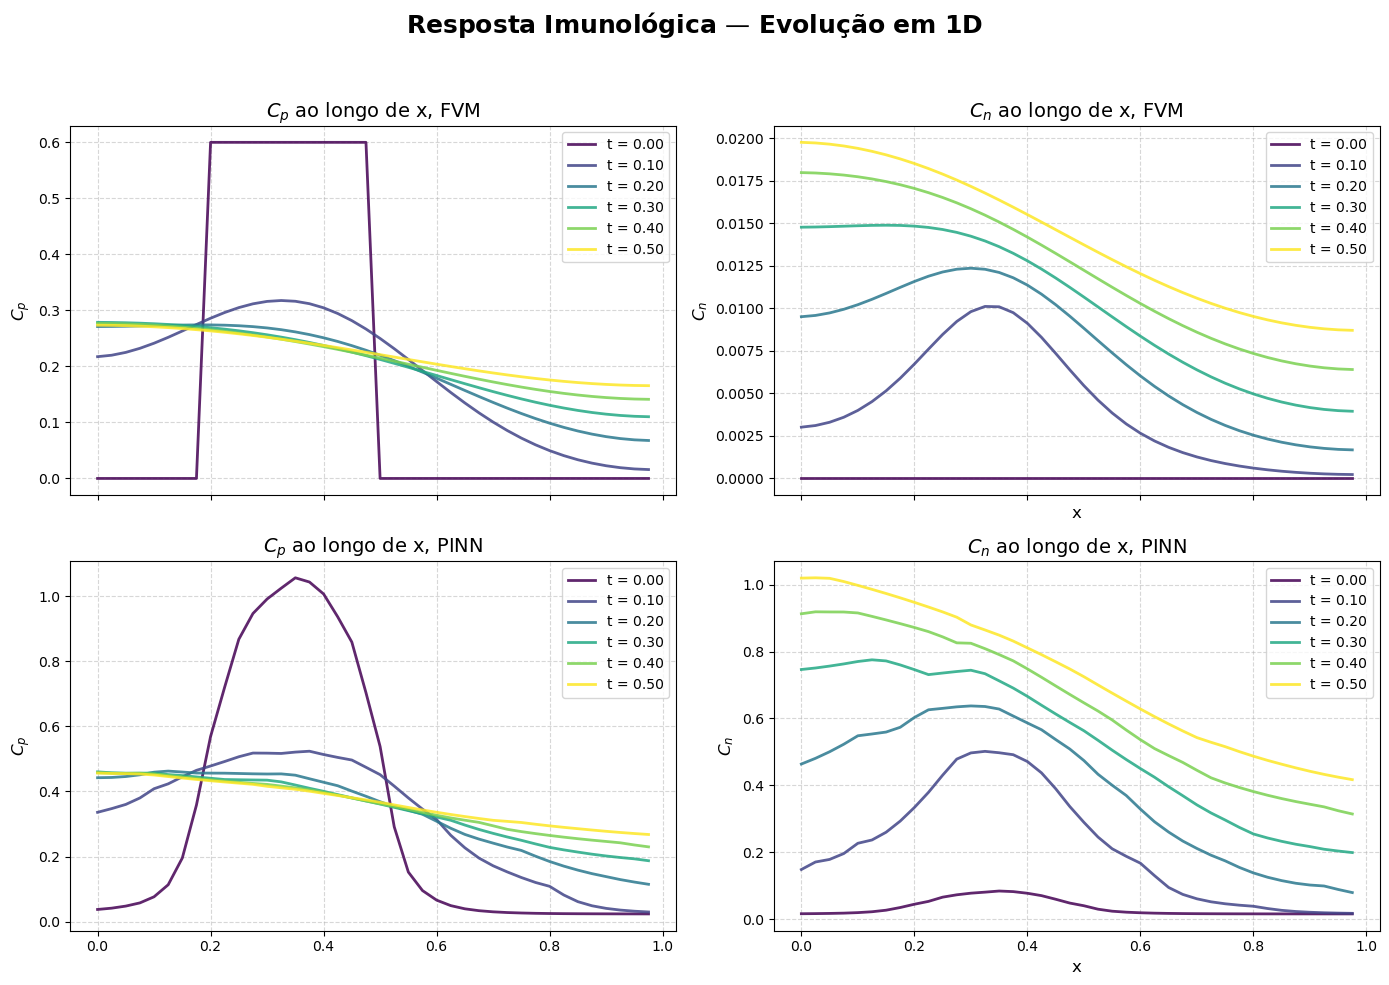

In [ ]:
# =====================================================
# NN: carrega modelo escolhido e prediz malha completa
# =====================================================

nn_model_path = "nn_parameters/" + nn_best_model["file"]
nn_model_path = nn_model_path.replace("nn__output_", "nn__")
nn_model_path = nn_model_path.replace(".pkl", ".pt")

nn_model = generate_model(
    nn_best_model["arch_name"],
    2,
    2
).to(device)

nn_model.load_state_dict(
    torch.load(
        nn_model_path,
        map_location=device,
        weights_only=True,
    )
)

nn_model.eval()

with torch.no_grad():
    pred_nn = nn_model(data_tc.to(device)).cpu().detach().numpy()

Cl_nn_np, Cp_nn_np = np.split(pred_nn, 2, axis=1)

Cl_nn_np = Cl_nn_np.reshape(Cp_fvm.shape)
Cp_nn_np = Cp_nn_np.reshape(Cp_fvm.shape)

# =====================================================
# Plot NN
# =====================================================

plot_comparison(
    size_t,
    size_x,
    t_dom,
    x_dom,
    Cp_fvm,
    Cl_fvm,
    Cp_nn_np,
    Cl_nn_np,
)

## Samples and noise

Total de experimentos carregados: 4
Figura salva em: figures_taylor/taylor_diagram_Cl.png


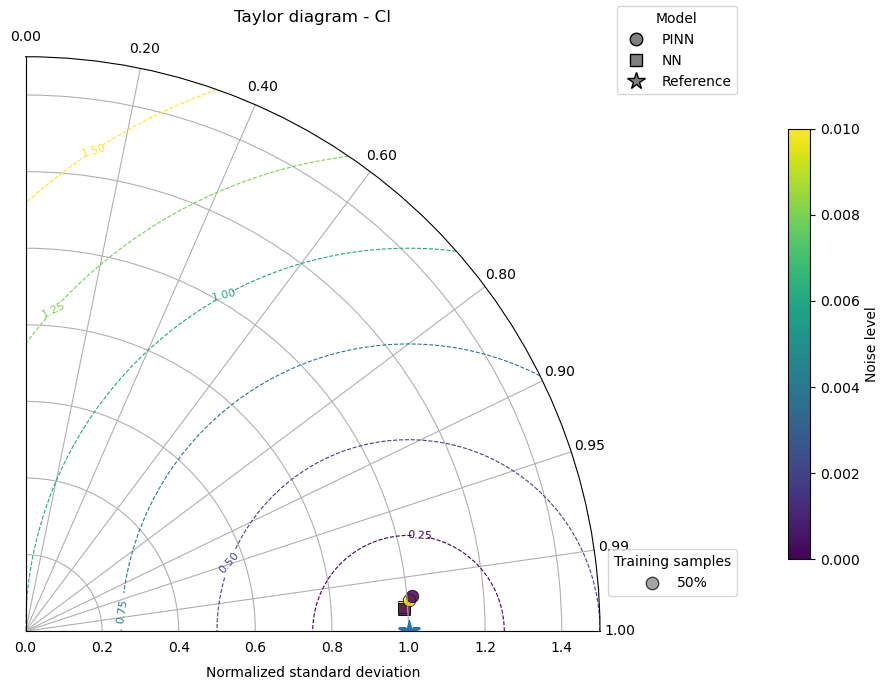

Figura salva em: figures_taylor/taylor_diagram_Cp.png


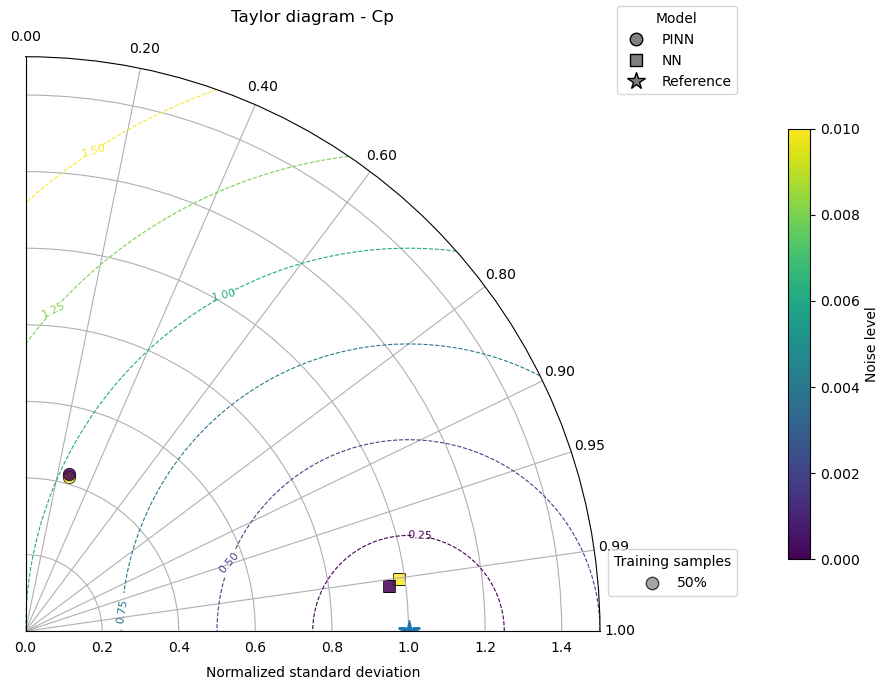

In [9]:
import os
import re
import glob
import pickle as pk

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


EXPERIMENT_DIR = "experiments"
OUTPUT_DIR = "figures_taylor"

VARIABLES = ["Cl", "Cp"]


def parse_experiment_filename(filepath):
    """
    Extrai:
    - modelo: PINN ou NN
    - noise_level
    - samples_percent

    Espera nomes como:
    pinn__prediction_all__noise--0.01__pct--20.pkl
    nn__prediction_all__noise--0.01__pct--20.pkl
    """

    filename = os.path.basename(filepath)

    model_match = re.match(r"(pinn|nn)__prediction_all__(.+)\.pkl", filename)

    if model_match is None:
        raise ValueError(f"Nome de arquivo não reconhecido: {filename}")

    model = model_match.group(1).upper()
    suffix = model_match.group(2)

    noise_match = re.search(r"noise--([0-9.eE+-]+)", suffix)
    pct_match = re.search(r"pct--([0-9.eE+-]+)", suffix)

    if noise_match is None or pct_match is None:
        raise ValueError(f"Não consegui extrair noise/pct de: {filename}")

    noise_level = float(noise_match.group(1))
    samples_percent = float(pct_match.group(1))

    return model, noise_level, samples_percent, suffix


def load_taylor_experiments(experiment_dir=EXPERIMENT_DIR):
    """
    Lê todos os arquivos prediction_all de PINN e NN.
    """

    files = sorted(
        glob.glob(os.path.join(experiment_dir, "pinn__prediction_all__*.pkl"))
        + glob.glob(os.path.join(experiment_dir, "nn__prediction_all__*.pkl"))
    )

    if len(files) == 0:
        raise FileNotFoundError(
            f"Nenhum arquivo prediction_all encontrado em: {experiment_dir}"
        )

    records = []

    for filepath in files:
        model, noise_level, samples_percent, suffix = parse_experiment_filename(filepath)

        with open(filepath, "rb") as f:
            data = pk.load(f)

        if "taylor_metrics" not in data:
            raise KeyError(
                f"O arquivo {filepath} não possui a chave 'taylor_metrics'."
            )

        record = {
            "model": model,
            "noise_level": noise_level,
            "samples_percent": samples_percent,
            "suffix": suffix,
            "filepath": filepath,
            "taylor_metrics": data["taylor_metrics"],
        }

        records.append(record)

    return records


def get_marker(model):
    """
    Marcador por modelo.
    """
    if model == "PINN":
        return "o"
    elif model == "NN":
        return "s"
    else:
        return "^"


def scale_marker_size(samples_percent, min_pct, max_pct):
    """
    Escala visual para representar a porcentagem de amostras.
    """

    if max_pct == min_pct:
        return 80

    return 50 + 150 * (samples_percent - min_pct) / (max_pct - min_pct)


def plot_taylor_diagram(
    records,
    variable,
    output_path=None,
    title=None,
    annotate=False,
):
    """
    Gera Taylor diagram normalizado.

    Usa:
    - normalized_std no raio;
    - correlation no ângulo;
    - centered RMSE normalizado como contornos.

    Cada ponto representa um experimento.
    PINN e NN aparecem no mesmo gráfico.
    """

    # Filtra registros que possuem a variável
    records = [
        r for r in records
        if variable in r["taylor_metrics"]
    ]

    if len(records) == 0:
        raise ValueError(f"Nenhum registro encontrado para a variável {variable}")

    noise_values = np.array([r["noise_level"] for r in records])
    pct_values = np.array([r["samples_percent"] for r in records])

    min_noise = float(np.min(noise_values))
    max_noise = float(np.max(noise_values))

    min_pct = float(np.min(pct_values))
    max_pct = float(np.max(pct_values))

    norm = Normalize(vmin=min_noise, vmax=max_noise)
    cmap = plt.cm.viridis

    # Coleta raio máximo
    radial_values = []

    for r in records:
        metric = r["taylor_metrics"][variable]
        radial_values.append(metric["normalized_std"])

    radial_values = np.array(radial_values, dtype=float)
    radial_values = radial_values[np.isfinite(radial_values)]

    r_max = max(1.5, 1.15 * np.max(radial_values))

    # Figura polar
    fig = plt.figure(figsize=(16, 7))
    ax = fig.add_subplot(111, polar=True)

    # Taylor diagram usual: correlação 1 em theta=0
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    # Limita para correlações positivas: 0 a 1
    ax.set_thetamin(0)
    ax.set_thetamax(90)

    ax.set_ylim(0, r_max)

    # Ticks de correlação
    corr_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.degrees(np.arccos(corr_ticks))

    ax.set_thetagrids(
        theta_ticks,
        labels=[f"{c:.2f}" if c < 1 else "1.00" for c in corr_ticks],
    )

    ax.set_xlabel("Normalized standard deviation", labelpad=20)

    # Referência
    ax.plot(
        0,
        1,
        marker="*",
        markersize=16,
        linestyle="None",
        label="Reference",
    )

    # Contornos de centered RMSE normalizado
    theta_grid = np.linspace(0, np.pi / 2, 300)
    r_grid = np.linspace(0, r_max, 300)

    theta_mesh, r_mesh = np.meshgrid(theta_grid, r_grid)

    crmse = np.sqrt(
        1.0
        + r_mesh**2
        - 2.0 * r_mesh * np.cos(theta_mesh)
    )

    crmse_levels = np.linspace(0.25, r_max, 6)

    contours = ax.contour(
        theta_mesh,
        r_mesh,
        crmse,
        levels=crmse_levels,
        linestyles="dashed",
        linewidths=0.8,
    )

    ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")

    # Plota os pontos
    for record in records:
        metric = record["taylor_metrics"][variable]

        corr = metric["correlation"]
        std_norm = metric["normalized_std"]

        if not np.isfinite(corr) or not np.isfinite(std_norm):
            continue

        corr = np.clip(corr, 0.0, 1.0)
        theta = np.arccos(corr)

        model = record["model"]
        noise_level = record["noise_level"]
        samples_percent = record["samples_percent"]

        marker = get_marker(model)
        color = cmap(norm(noise_level))
        size = scale_marker_size(samples_percent, min_pct, max_pct)

        ax.scatter(
            theta,
            std_norm,
            marker=marker,
            s=size,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.85,
        )

        if annotate:
            label = f"{model}\n{samples_percent:g}%/{noise_level:g}"
            ax.text(
                theta,
                std_norm,
                label,
                fontsize=7,
                ha="left",
                va="bottom",
            )

    # Legenda dos modelos
    model_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=9,
            label="PINN",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="none",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=9,
            label="NN",
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color="none",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=13,
            label="Reference",
        ),
    ]

    legend1 = ax.legend(
        handles=model_handles,
        loc="upper right",
        bbox_to_anchor=(1.25, 1.10),
        title="Model",
    )

    ax.add_artist(legend1)

    # Legenda de tamanho: porcentagem de amostras
    unique_pcts = sorted(set(pct_values))

    size_handles = []

    for pct in unique_pcts:
        size = scale_marker_size(pct, min_pct, max_pct)
        size_handles.append(
            plt.scatter(
                [],
                [],
                s=size,
                color="gray",
                edgecolor="black",
                alpha=0.7,
                label=f"{pct:g}%",
            )
        )

    ax.legend(
        handles=size_handles,
        loc="lower right",
        bbox_to_anchor=(1.25, 0.05),
        title="Training samples",
    )

    # Colorbar para ruído
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.12,
        shrink=0.75,
    )

    cbar.set_label("Noise level")

    if title is None:
        title = f"Taylor diagram - {variable}"

    ax.set_title(title, pad=25)

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Figura salva em: {output_path}")

    plt.show()


os.makedirs(OUTPUT_DIR, exist_ok=True)

records = load_taylor_experiments(EXPERIMENT_DIR)

print(f"Total de experimentos carregados: {len(records)}")

for variable in VARIABLES:
    output_path = os.path.join(
        OUTPUT_DIR,
        f"taylor_diagram_{variable}.png",
    )

    plot_taylor_diagram(
        records,
        variable=variable,
        output_path=output_path,
        title=f"Taylor diagram - {variable}",
        annotate=False,
    )